In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : Air Quality Prediction (UCI)
Algorithm : Long Short-Term Memory (LSTM) – PyTorch
"""
import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from torch import nn, optim


c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


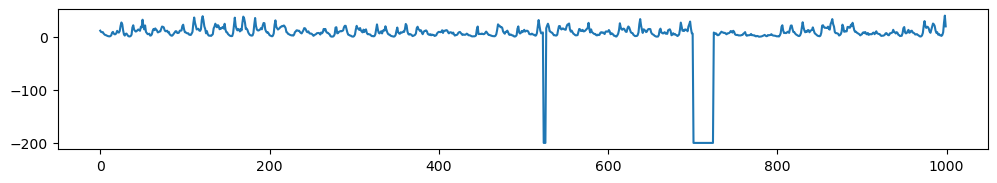

In [2]:
#%% load dataset 
filename= r'AirQualityUCI.xlsx'
df= pd.read_excel(filename)

names= df.columns
target= df.iloc[:,5].to_numpy()
df= df.drop(names[5], axis=1)
data= df.iloc[:,2:].to_numpy()

data[np.isnan(data)]=0
target[np.isnan(target)]=0

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(target[:1000])
plt.show()

In [3]:
Xtrain,Xtest,y_train,y_test=train_test_split(data,target,
                                                 train_size=0.7,
                                                 shuffle=False)

In [4]:
# standardize
scaler= prep.StandardScaler()
Xtrain= scaler.fit_transform(Xtrain)
Xtest= scaler.transform(Xtest)

In [5]:
def sequence_data(data,target,step):
    tau= step
    data_seq=[]
    target_seq= []
    for i in range(tau,data.shape[0],1):
        d= data[i-tau:i]
        y= target[i-tau:i]
        data_seq.append(d)
        target_seq.append(y)
        # print(i)
    data_seq = np.array(data_seq)
    target_seq = np.array(target_seq)
    return data_seq,target_seq

Xtrain_seq,y_train_seq= sequence_data(Xtrain,y_train,step=5)
Xtest_seq,y_test_seq= sequence_data(Xtest,y_test,step=5)
print(Xtrain_seq.shape,y_train_seq.shape)
print(Xtest_seq.shape,y_test_seq.shape)

(6544, 5, 12) (6544, 5)
(2803, 5, 12) (2803, 5)


In [6]:
#%% convert to tensor
Xtrain= torch.from_numpy(Xtrain_seq).type(torch.float32)
y_train= torch.from_numpy(y_train_seq).type(torch.float32)

Xtest= torch.from_numpy(Xtest_seq).type(torch.float32)
y_test= torch.from_numpy(y_test_seq).type(torch.float32)

In [7]:
class LSTM_Regressor(nn.Module):
    def __init__(self, input_size,
                 hidden_size=128, 
                 num_layers=1,
                 num_out=1,
                 dropout= 0.3,
                 bidirectional=False):
        super(LSTM_Regressor, self).__init__()
        self.lstm = nn.LSTM(input_size, 
                            hidden_size,
                            num_layers,
                            bidirectional=bidirectional,
                            batch_first=True,
                            dropout=dropout if num_layers>1 else 0.0)
        self.lstm.num_layers= num_layers
        self.lstm.hidden_size= hidden_size
        D= int(self.lstm.bidirectional) +1
        self.fc1 = nn.Linear(hidden_size*D, num_out)
        # self.fc = nn.Linear(hidden_size, num_out)
        self.fun= nn.ReLU()
    
    def forward(self, x,h0=None,c0=None):
        num_layers = self.lstm.num_layers
        hidden_size = self.lstm.hidden_size
        D= int(self.lstm.bidirectional) +1
        batch_size= x.size(0)
        if h0 is None or c0 is None:
            h_prev = torch.zeros(num_layers*D, batch_size, hidden_size)
            c_prev = torch.zeros(num_layers*D, batch_size, hidden_size)
        else:
            h_prev = h0
            c_prev = c0
        x= x.squeeze(1)  # Remove the extra dimension
        out, (ht,ct) = self.lstm(x, (h_prev, c_prev))
        # many to many LSTM
        out = self.fc1(out)
        
        # out= self.fun(out)
        # out = self.fc(out)
        return out,ht,ct

In [8]:
#% build data loader 
ds= TensorDataset(Xtrain,y_train)
train_loader= DataLoader(ds,batch_size=32,
                         shuffle=False,
                         drop_last=True)

#% build data loader 
ds_test= TensorDataset(Xtest,y_test)
test_loader= DataLoader(ds_test,batch_size=32,
                         shuffle=False,
                         drop_last=True)

In [9]:
#%% train Neural Network
torch.manual_seed(1)
n_features=Xtrain_seq.shape[2]
model= LSTM_Regressor(input_size=n_features,
                    hidden_size=32,
                    num_layers=2,
                    num_out=1,
                    bidirectional=True,
                    dropout=0.3)

criterion= nn.MSELoss()
optimizer= optim.Adam(model.parameters(),lr=0.01)

In [10]:
num_epochs = 20
h0 = None
c0 = None
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs,ht,ct = model(inputs,h0,c0)
        h0= ht.detach()
        c0= ct.detach()
        loss = criterion(outputs.squeeze(), labels)
        loss.backward()

        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [1/20], Loss: 952.5815
Epoch [2/20], Loss: 659.1856
Epoch [3/20], Loss: 427.4706
Epoch [4/20], Loss: 287.2626
Epoch [5/20], Loss: 189.6648
Epoch [6/20], Loss: 121.3853
Epoch [7/20], Loss: 75.0621
Epoch [8/20], Loss: 44.8499
Epoch [9/20], Loss: 25.5707
Epoch [10/20], Loss: 14.9691
Epoch [11/20], Loss: 8.7777
Epoch [12/20], Loss: 5.4016
Epoch [13/20], Loss: 4.1167
Epoch [14/20], Loss: 3.5884
Epoch [15/20], Loss: 3.3200
Epoch [16/20], Loss: 2.8643
Epoch [17/20], Loss: 2.6178
Epoch [18/20], Loss: 2.4210
Epoch [19/20], Loss: 2.0751
Epoch [20/20], Loss: 1.8073


In [11]:
with torch.no_grad():
    model.eval()
    correct = 0
    total = 0
    ypred_list = []
    ytrue_list = []
    h0,c0 = None,None
    for inputs, labels in test_loader:
        predicted,ht,ct = model(inputs,h0,c0)
        h0= ht.detach()
        c0= ct.detach()
        
        ypred_list.extend(predicted[-1].numpy())
        ytrue_list.extend(labels[-1].numpy())



ypred= np.array(ypred_list).ravel()
d_test= np.array(ytrue_list).ravel()

In [12]:

print(ypred.shape,d_test.shape)

(435,) (435,)


MSE:4.304
MAE:0.910
R square:0.998


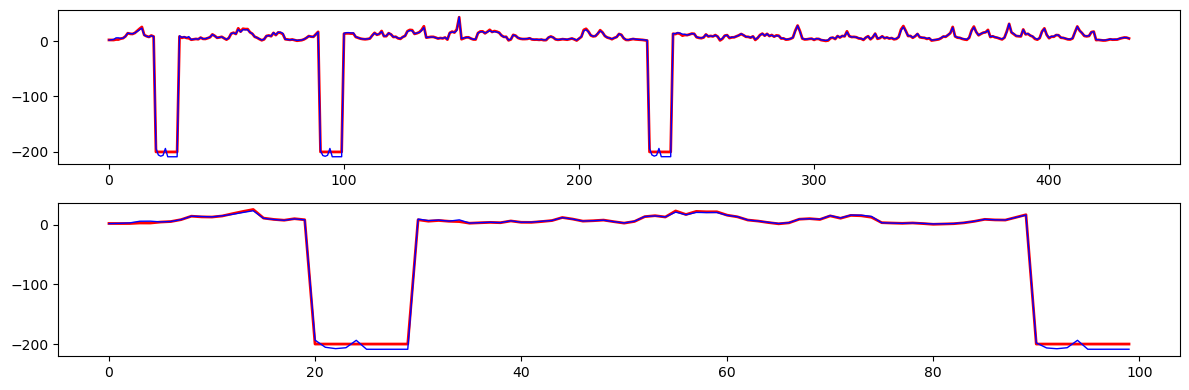

In [13]:
#%% validate your Neural Network
MSE= metrics.mean_squared_error(d_test,ypred)
MAE= metrics.mean_absolute_error(d_test,ypred)
r2= metrics.r2_score(d_test,ypred)

print(f'MSE:{MSE:.3f}')
print(f'MAE:{MAE:.3f}')
print(f'R square:{r2:.3f}')

plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(d_test,'r',linewidth=2)
plt.plot(ypred,'b',linewidth=1)
plt.subplot(2,1,2)
plt.plot(d_test[:100],'r',linewidth=2)
plt.plot(ypred[:100],'b',linewidth=1)
plt.tight_layout()
plt.show()